Supervised model 
- sees individual indicators (RSI = 72, MACD = 1.3, HV = 0.25). 
But it does not inherently know that this combination means "late stage bull run with rising volatility"

Unsupervised learns these combinations and gives them a label:
- Regime 0: low volatility, trending up, low volume - calm bull
- Regime 1: high volatility, no trend, high volume - choppy/uncertain
- Regime 2: high volatility, trending down, high volume - sell-off

Then, the supervised model can learn: "in Regime 0, my momentum signals work. In Regime 1, sit out, In Regime 2, short"

Without unsupervised: the supervised model has to figure out these combinations itself from raw numbers. It can, but it's harder.
With unsupervised: you hand it the answer — "today is a Regime 1 day" — and it just has to learn what to do in each regime.

Unsupervised Model of Choice - Hidden Markov Model - "What state is the market right now"?
- Hidden Markov Model — it assumes the market has hidden "states" (regimes) that you can't observe directly, but you can infer them from observable data (returns, volatility).
- "Hidden" = you don't see the regime directly. Nobody rings a bell when a bear market starts.
- "Markov" = tomorrow's regime depends only on today's regime, not the full history. If we're in a bull market today, there's e.g. a 95% chance we stay bull tomorrow, 5% chance we switch to bear.
- "Model" = it learns the transition probabilities and what each regime "looks like" (e.g., Regime 0 has mean return +0.05% and low std, Regime 1 has mean return -0.1% and high std).

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix
from hmmlearn.hmm import GaussianHMM

TICKER = "AAPL"
INTERVAL = "1d"
PERIOD = "max"
LOOKBACK = 10000
N_REGIMES = 3

# Fetch data
df = yf.download(TICKER, session=yfinance_fix.chrome_session, interval=INTERVAL, period=PERIOD)
df.columns = df.columns.get_level_values(0)
df = df.iloc[-LOOKBACK:, :]

# Observable features for HMM: log returns + volatility
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["hv_5"] = df["log_return"].rolling(5).std()
df = df.dropna()

print(f"Rows: {len(df)}")
df.tail(5)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Rows: 9995


Price,Close,High,Low,Open,Volume,log_return,hv_5
Date,,,,,,,
2026-04-14,258.829987,261.929993,257.190002,259.250000,48370700,-0.001429,0.010265
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500,0.028940,0.013573
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100,-0.011438,0.015572
2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200,0.025600,0.018574
2026-04-20,273.049988,274.279999,270.290009,270.329987,36472700,0.010381,0.017260


Step 1: Fit HMM

Feed the model log returns + short-term volatility. It discovers N_REGIMES hidden states and learns:
- The mean and variance of returns in each regime
- The transition probabilities (how likely is it to switch from regime A to regime B)

In [4]:
# Fit Gaussian HMM on log returns + volatility
X_hmm = df[["log_return", "hv_5"]].values

hmm = GaussianHMM(n_components=N_REGIMES, covariance_type="full", n_iter=200, random_state=42)
hmm.fit(X_hmm)

# Predict most likely regime for each day
df["regime"] = hmm.predict(X_hmm)

# Sort regimes by mean return (0 = lowest return, 2 = highest return)
regime_means = df.groupby("regime")["log_return"].mean().sort_values()
regime_map = {old: new for new, old in enumerate(regime_means.index)}
df["regime"] = df["regime"].map(regime_map)

print("Regime characteristics:")
for r in sorted(df["regime"].unique()):
    subset = df[df["regime"] == r]
    print(f"  Regime {r}: mean_return={subset['log_return'].mean():.5f}, "
          f"std={subset['log_return'].std():.5f}, "
          f"days={len(subset)} ({len(subset)/len(df):.1%})")

Regime characteristics:
  Regime 0: mean_return=0.00031, std=0.05706, days=1229 (12.3%)
  Regime 1: mean_return=0.00052, std=0.02518, days=4232 (42.3%)
  Regime 2: mean_return=0.00113, std=0.01245, days=4534 (45.4%)


Step 2: Visualize regimes on price chart

Color-code the price by detected regime. This shows when the HMM thinks the market is in each state.

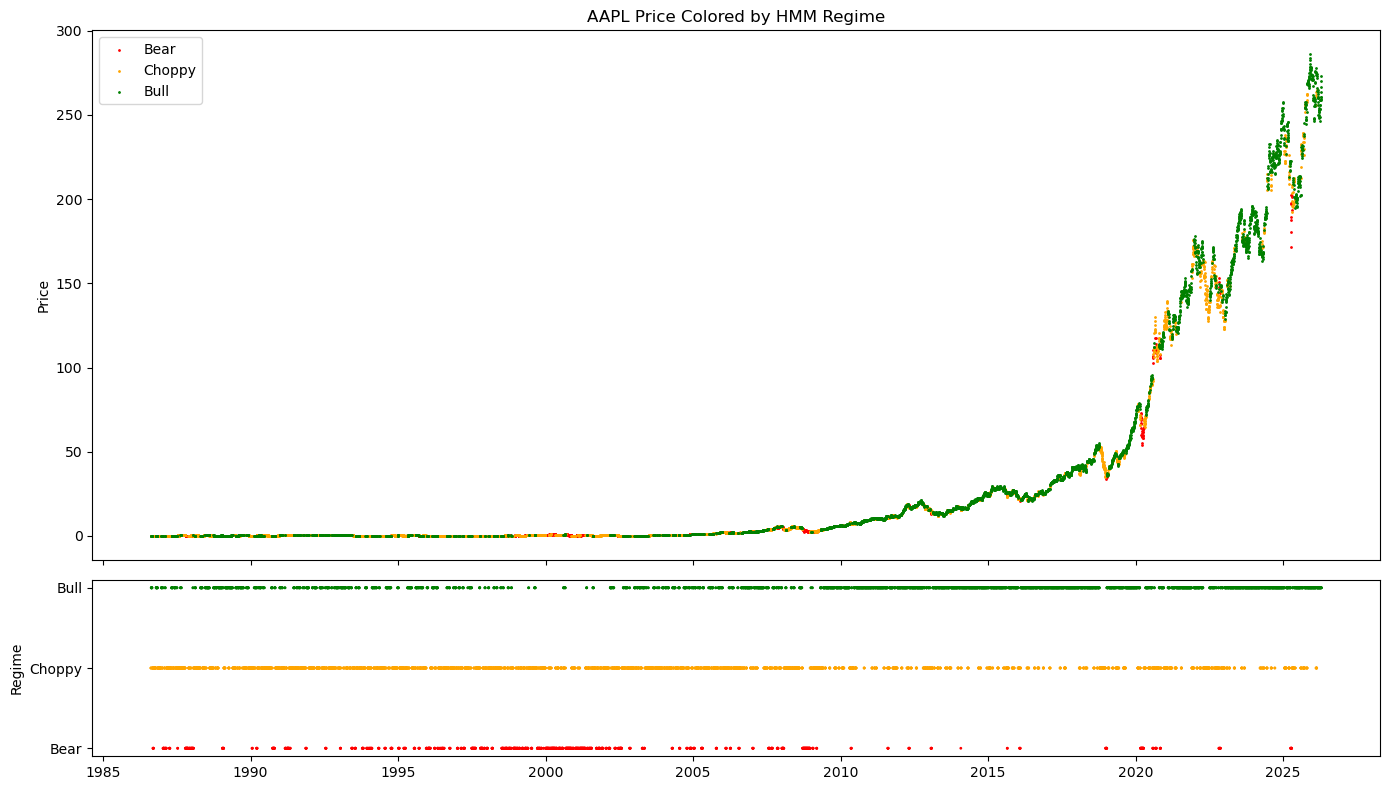

In [5]:
# Price chart colored by regime
colors = {0: "red", 1: "orange", 2: "green"}
labels = {0: "Bear", 1: "Choppy", 2: "Bull"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# Top: price with regime background
for r in sorted(df["regime"].unique()):
    mask = df["regime"] == r
    ax1.scatter(df.index[mask], df["Close"][mask], c=colors[r], s=1, label=labels[r])
ax1.set_title(f"{TICKER} Price Colored by HMM Regime")
ax1.set_ylabel("Price")
ax1.legend()

# Bottom: regime timeline
ax2.scatter(df.index, df["regime"], c=df["regime"].map(colors), s=1)
ax2.set_ylabel("Regime")
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["Bear", "Choppy", "Bull"])
plt.tight_layout()
plt.show()

Step 3: Transition matrix

Shows the probability of switching between regimes. High diagonal values = regimes are sticky (market stays in the same state). Off-diagonal = probability of regime change.

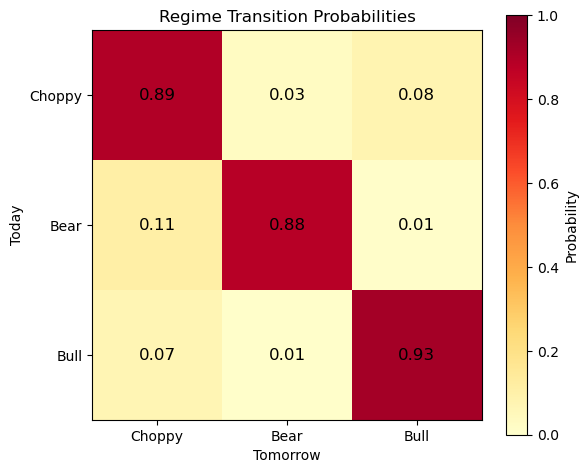

In [6]:
# Transition matrix: P(regime_tomorrow | regime_today)
trans = pd.DataFrame(
    hmm.transmat_,
    index=[labels[regime_map[i]] for i in range(N_REGIMES)],
    columns=[labels[regime_map[i]] for i in range(N_REGIMES)]
)

plt.figure(figsize=(6, 5))
plt.imshow(trans.values, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(label="Probability")
for i in range(N_REGIMES):
    for j in range(N_REGIMES):
        plt.text(j, i, f"{trans.values[i, j]:.2f}", ha="center", va="center", fontsize=12)
plt.xticks(range(N_REGIMES), trans.columns)
plt.yticks(range(N_REGIMES), trans.index)
plt.title("Regime Transition Probabilities")
plt.xlabel("Tomorrow")
plt.ylabel("Today")
plt.tight_layout()
plt.show()

Step 4: Does the regime label improve supervised learning?

Compare LogReg accuracy with and without the regime feature. If accuracy improves, the HMM adds value and should be included in the app.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Compute all 11 features on the same df
df["momentum_21d"] = df["Close"].pct_change(21)
df["momentum_252_21d"] = df["Close"].pct_change(252) - df["Close"].pct_change(21)
log_ret = np.log(df["Close"] / df["Close"].shift(1))
df["vol_ratio"] = log_ret.rolling(5).std() / log_ret.rolling(20).std()
df["hv_20"] = log_ret.rolling(20).std() * np.sqrt(252)
df["illiquidity"] = (log_ret.abs() / df["Volume"]).rolling(20).mean()
df["autocorr_20"] = log_ret.rolling(20).apply(lambda x: x.autocorr(lag=1))

price_change = df["Close"].diff()
gain = price_change.where(price_change > 0, 0)
loss = -price_change.where(price_change < 0, 0)
df["RSI"] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean()))
ema_fast = df["Close"].ewm(span=12).mean()
ema_slow = df["Close"].ewm(span=26).mean()
macd_line = ema_fast - ema_slow
df["MACD_HIST"] = macd_line - macd_line.ewm(span=9).mean()
high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
df["ATR"] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1).rolling(14).mean()
sma = df["Close"].rolling(20).mean()
rstd = df["Close"].rolling(20).std()
df["BB_Percent"] = (df["Close"] - (sma - 2 * rstd)) / (4 * rstd)
typical = (df["High"] + df["Low"] + df["Close"]) / 3
mf = typical * df["Volume"]
delta = typical.diff()
df["MFI"] = 100 - (100 / (1 + mf.where(delta > 0, 0).rolling(14).sum() / mf.where(delta < 0, 0).rolling(14).sum()))

# Target
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.iloc[:-1]

# Feature sets: without and with regime
base_features = ["momentum_21d", "momentum_252_21d", "vol_ratio", "hv_20", "illiquidity", "autocorr_20",
                 "RSI", "MACD_HIST", "ATR", "BB_Percent", "MFI"]
regime_features = base_features + ["regime"]

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=regime_features + ["Target"])

# Temporal split
split_idx = int(len(df_clean) * 0.8)
train = df_clean.iloc[:split_idx - 1]
test = df_clean.iloc[split_idx:]

results = {}
for name, feats in [("Without HMM", base_features), ("With HMM", regime_features)]:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[feats])
    X_te = scaler.transform(test[feats])
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, train["Target"])
    preds = model.predict(X_te)
    
    acc = accuracy_score(test["Target"], preds)
    f1 = f1_score(test["Target"], preds, zero_division=0)
    results[name] = {"accuracy": acc, "f1": f1}
    print(f"{name:>15s}: accuracy={acc:.4f}, f1={f1:.4f}")

diff = results["With HMM"]["accuracy"] - results["Without HMM"]["accuracy"]
print(f"\nAccuracy difference: {diff:+.4f}")
if diff > 0.005:
    print("HMM regime label improves the model — consider adding it to the app.")
elif diff > -0.005:
    print("Marginal difference — HMM regime has little impact.")
else:
    print("HMM regime hurts accuracy — do not include it.")

    Without HMM: accuracy=0.4900, f1=0.4228
       With HMM: accuracy=0.4910, f1=0.4318

Accuracy difference: +0.0010
Marginal difference — HMM regime has little impact.
